In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gpflow
from scipy.stats.distributions import chi2
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from gpflow.utilities import print_summary, positive
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from gpflow import set_trainable
from utilities import fit_rbf, fit_noise
from mpl_toolkits.mplot3d import Axes3D
import random
from scipy.stats.distributions import chi2
np.set_printoptions(suppress=True)
f64 = gpflow.utilities.to_default_float

In [13]:
def load_data_separate(data, gene_id, samples_exp1, samples_exp2):

    y_exp1 = data[data['Unnamed: 0'] == gene_id][samples_exp1].to_numpy().reshape(-1,1)
    y_exp2 = data[data['Unnamed: 0'] == gene_id][samples_exp2].to_numpy().reshape(-1,1)

    TU_IMI_exp1 = metadata[metadata['experiment']==1]['conc_IMI'].to_numpy().reshape(-1,1)
    TU_IMI_exp2 = metadata[metadata['experiment']==2]['conc_IMI'].to_numpy().reshape(-1,1)

    TU_CLO_exp1 = metadata[metadata['experiment']==1]['conc_CLO'].to_numpy().reshape(-1,1)
    TU_CLO_exp2 = metadata[metadata['experiment']==2]['conc_CLO'].to_numpy().reshape(-1,1)

    TU_CYPRO_exp1 = metadata[metadata['experiment']==1]['conc_CYPRO'].to_numpy().reshape(-1,1)
    TU_CYPRO_exp2 = metadata[metadata['experiment']==2]['conc_CYPRO'].to_numpy().reshape(-1,1)

    df_exp1 = pd.concat([pd.DataFrame(TU_IMI_exp1), pd.DataFrame(TU_CLO_exp1), pd.DataFrame(y_exp1)], axis=1)
    df_exp2 = pd.concat([pd.DataFrame(TU_IMI_exp2), pd.DataFrame(TU_CYPRO_exp2), pd.DataFrame(y_exp2)], axis=1)

    df_exp1.columns = ['conc_IMI', 'conc_CLO', 'y_exp1']
    df_exp2.columns = ['conc_IMI', 'conc_CYPRO', 'y_exp2']

    y_exp1 =  df_exp1['y_exp1'].to_numpy().reshape(-1,1)
    y_exp1 = (y_exp1 - np.min(y_exp1))/(np.max(y_exp1)-np.min(y_exp1))
    x_exp1 = np.hstack((df_exp1['conc_IMI'].to_numpy().reshape(-1,1), df_exp1['conc_CLO'].to_numpy().reshape(-1,1)))

    y_exp2 = df_exp2['y_exp2'].to_numpy().reshape(-1,1)
    x_exp2 = np.hstack((df_exp2['conc_IMI'].to_numpy().reshape(-1,1), df_exp2['conc_CYPRO'].to_numpy().reshape(-1,1)))
    y_exp2 = (y_exp2 - np.min(y_exp2))/(np.max(y_exp2)-np.min(y_exp2))

    return (x_exp1, y_exp1, x_exp2, y_exp2)


def load_data(data, gene_id, samples_exp1, samples_exp2):

    y_exp1 = data[data['Unnamed: 0'] == gene_id][samples_exp1].to_numpy().reshape(-1,1)
    y_exp2 = data[data['Unnamed: 0'] == gene_id][samples_exp2].to_numpy().reshape(-1,1)

    TU_IMI_exp1 = metadata[metadata['experiment']==1]['conc_IMI'].to_numpy().reshape(-1,1)
    TU_IMI_exp2 = metadata[metadata['experiment']==2]['conc_IMI'].to_numpy().reshape(-1,1)

    TU_CLO_exp1 = metadata[metadata['experiment']==1]['conc_CLO'].to_numpy().reshape(-1,1)
    TU_CLO_exp2 = metadata[metadata['experiment']==2]['conc_CLO'].to_numpy().reshape(-1,1)

    TU_CYPRO_exp1 = metadata[metadata['experiment']==1]['conc_CYPRO'].to_numpy().reshape(-1,1)
    TU_CYPRO_exp2 = metadata[metadata['experiment']==2]['conc_CYPRO'].to_numpy().reshape(-1,1)

    df_exp1 = pd.concat([pd.DataFrame(TU_IMI_exp1), pd.DataFrame(TU_CLO_exp1), pd.DataFrame(y_exp1)], axis=1)
    df_exp2 = pd.concat([pd.DataFrame(TU_IMI_exp2), pd.DataFrame(TU_CYPRO_exp2), pd.DataFrame(y_exp2)], axis=1)

    df_exp1.columns = ['conc_IMI', 'conc_CLO', 'y_exp1']
    df_exp2.columns = ['conc_IMI', 'conc_CYPRO', 'y_exp2']
    df_exp1.columns = ['', '', '']
    df_exp2.columns = ['', '', '']

    df = pd.concat([df_exp1, df_exp2], axis=0)
    df.columns = ['conc_drug1', 'conc_drug2', 'y']
    df['conc_drug12'] = df['conc_drug1']*df['conc_drug2']
    df_X = pd.concat([df['conc_drug1'], df['conc_drug2'], df['conc_drug12']], axis=1)
    df_X.columns = ['','','']
    X_full = df_X.to_numpy()
    Y_full = df['y'].to_numpy().reshape(-1,1)
    #Y_full = (Y_full - np.min(Y_full))/(np.max(Y_full)-np.min(Y_full))

    return (X_full, Y_full)

def likelihood_ratio(llmin, llmax):
    return(2*(llmax-llmin))

In [14]:
data_full_exp1 = pd.read_csv('../data/raw_exp1.csv')
data_full_exp2 = pd.read_csv('../data/raw_exp2.csv')
data_full_exp2 = data_full_exp2.drop(columns=['Unnamed: 0'])
metadata = pd.read_csv('../data/metadata.csv')

data_full = pd.concat([data_full_exp1, data_full_exp2], axis=1)

genes = data_full['Unnamed: 0'].to_numpy()
subset = data_full[data_full['Unnamed: 0'].isin(genes)]

samples_exp1 = metadata[metadata['experiment']==1]['sample']
samples_exp1 = samples_exp1.to_numpy().astype(str).tolist()

samples_exp2 = metadata[metadata['experiment']==2]['sample']
samples_exp2 = samples_exp2.to_numpy().astype(str).tolist()

string = 'Sample_'
samples_exp1 = [string + x for x in samples_exp1]
samples_exp2 = [string + x for x in samples_exp2]

loglik_rbf_exp1_list = []
loglik_rbf_exp2_list = []

loglik_noise_exp1_list = []
loglik_noise_exp2_list = []

genes_list = []

mlik_noise_exp1 = []
mlik_noise_exp2 = []
mlik_rbf_exp1 = []
mlik_rbf_exp2 = []

lengthscale_rbf_exp1 = []
variance_rbf_exp1 = []
lengthscale_rbf_exp2 = []
variance_rbf_exp2 = []

variance_noise_exp1 = []
variance_noise_exp2 = []

genesID = []

Test_stat = []
p_val = []

t_df = []
trt_df = []
y_df = []
ID_df = []

In [15]:
# Define ID of the gene we want to make an example for
gene_id = 'Fcan01_00630' # original example in the paper
#gene_id = 'Fcan01_00005' # additional example in the paper
num_example = 4 # choose for saving figure
num_example = 5 # choose for saving figure

# Choose if CI for noise should be plotted
plot_noise = True

# Load the data
data = load_data_separate(data_full, gene_id, samples_exp1, samples_exp2)
data_exp1 = (data[0], data[1])
data_exp2 = (data[2], data[3])

# Put the data in data frame
df_exp1 = pd.DataFrame(np.concatenate((data[0][:,0].reshape(-1,1), data[0][:,1].reshape(-1,1),data[1].reshape(-1,1)), axis=-1))
df_exp2 = pd.DataFrame(np.concatenate((data[2][:,0].reshape(-1,1), data[2][:,1].reshape(-1,1),data[3].reshape(-1,1)), axis=-1))

df_exp1.columns = ['drug1', 'drug2', 'effect']
df_exp2.columns = ['drug1', 'drug2', 'effect']

df_exp1_imi = df_exp1[df_exp1['drug2']==0.0]
df_exp2_imi = df_exp2[df_exp2['drug2']==0.0]

X_exp1 = df_exp1_imi['drug1'].to_numpy()
Y_exp1 = df_exp1_imi['effect'].to_numpy()

X_exp2 = df_exp2_imi['drug1'].to_numpy()
Y_exp2 = df_exp2_imi['effect'].to_numpy()

# Put the data into the right format for inference
data_exp1 = (X_exp1.reshape(-1,1), Y_exp1.reshape(-1,1))
data_exp2 = (X_exp2 .reshape(-1,1), Y_exp2.reshape(-1,1))

t0 = np.unique(X_exp1)

## Dynamic model

Dynamic likelihood -12.350257483783025


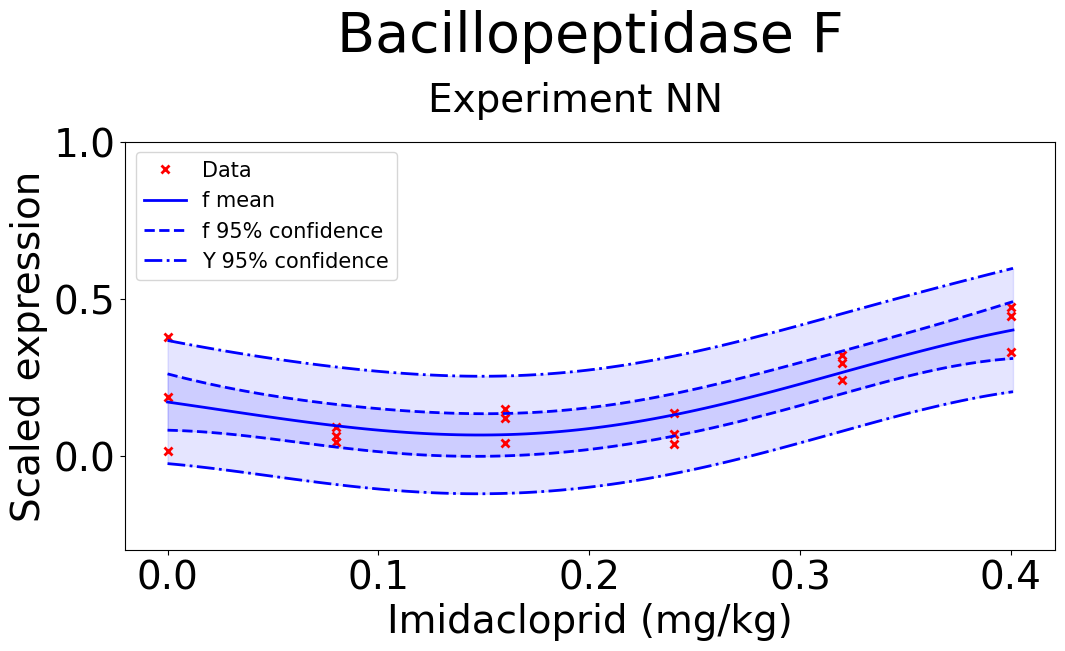

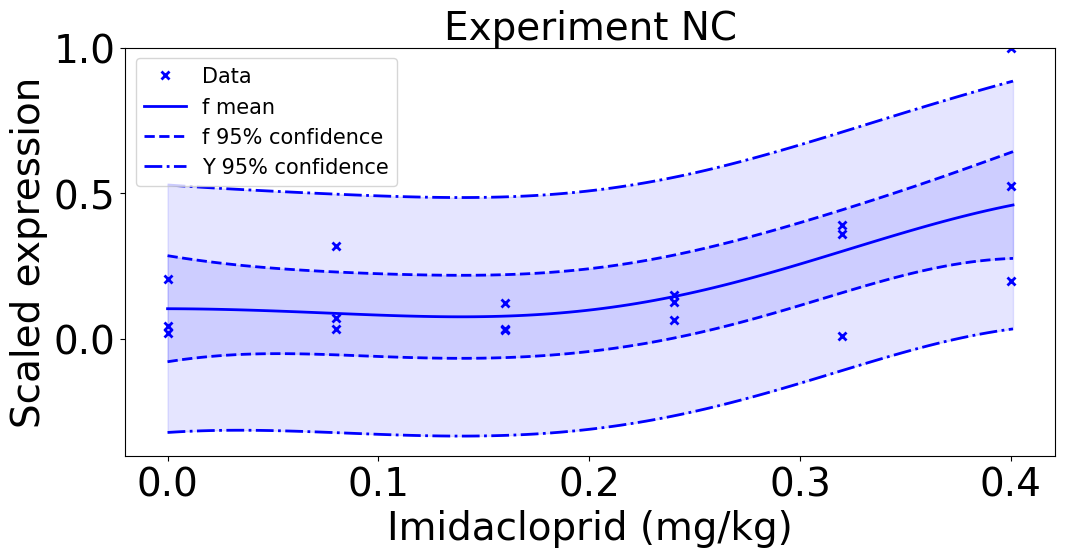

In [16]:
"""
Fit two models on exp1
"""
# fit rbf mrna
init_lengthscale = 0.2
init_variance = 1.0
m, lik = fit_rbf(data_exp1, init_lengthscale, init_variance)


print('Dynamic likelihood', lik)

k = gpflow.kernels.RBF()
#k.lengthscales.assign(np.asarray(m.kernel.lengthscales.read_value()))
#k.variance.assign(np.asarray(m.kernel.variance.read_value()))

k.lengthscales.assign(np.asarray(m.kernel.lengthscales).flatten()[0])
k.variance.assign(np.asarray(m.kernel.variance).flatten()[0])

## generate test points for prediction
#num_predict = 100
xx = np.linspace(0.0, 0.401, 100).reshape(100, 1)  # test points must be of shape (N, D)

## predict mean and variance of latent GP at test points
mean, var = m.predict_f(xx)
mean_y, var_y = m.predict_y(xx)

mean_exp1 = np.asarray(mean)
K_exp1 = k(xx,xx)

mlik_rbf_exp1.append(lik)
#lengthscale_rbf_exp1.append(np.asarray(m.kernel.lengthscales.read_value()))
#variance_rbf_exp1.append(np.asarray(m.kernel.variance.read_value()))

lengthscale_rbf_exp1.append(np.asarray(m.kernel.lengthscales).flatten()[0])
variance_rbf_exp1.append(np.asarray(m.kernel.variance).flatten()[0])

# # Plot predicted model
plt.figure(figsize=(12, 6))
plt.plot(X_exp1.flatten(), Y_exp1.flatten(), 'rx', mew=2, label="Data")
plt.plot(xx[:, 0], mean[:, 0], 'b', lw=2, label="f mean")
plt.plot(xx[:, 0], mean[:, 0] - 2 * np.sqrt(var[:, 0]), 'b--', lw=2, label="f 95% confidence")
plt.plot(xx[:, 0], mean[:, 0] + 2 * np.sqrt(var[:, 0]), 'b--', lw=2)

plt.plot(xx[:, 0], mean_y[:, 0] - 2 * np.sqrt(var_y[:, 0]), color='blue', linestyle='dashdot', lw=2, label="Y 95% confidence")
plt.plot(xx[:, 0], mean_y[:, 0] + 2 * np.sqrt(var_y[:, 0]), color='blue', linestyle='dashdot', lw=2)

plt.fill_between(xx[:, 0],
                 mean[:, 0] - 2 * np.sqrt(var[:, 0]),
                 mean[:, 0] + 2 * np.sqrt(var[:, 0]),
                 color='blue',
                 alpha=0.1)

plt.fill_between(xx[:, 0],
             mean_y[:, 0] - 2 * np.sqrt(var_y[:, 0]),
             mean_y[:, 0] + 2 * np.sqrt(var_y[:, 0]),
             color='blue',
             alpha=0.1)

#plt.savefig('imi_filtering/'+str(i)+'_exp1'+'.png')
plt.tick_params(axis='x', labelsize=28)
plt.tick_params(axis='y', labelsize=28)
plt.xlabel('Imidacloprid (mg/kg)', fontsize=28)
plt.ylabel('Scaled expression', fontsize=28)
#plt.title('Experiment NN', fontsize=28)

#plt.rc('text', usetex=True)
#plt.title(r'\fontsize{40pt}{3em}\selectfont{}{Bacillopeptidase F\r}{\fontsize{28pt}{3em}\selectfont{}(Experiment NN)}')

plt.title('Bacillopeptidase F\n', fontsize=40, pad=20)
plt.suptitle('Experiment NN\n', fontsize=28)

plt.subplots_adjust(bottom=0.2)
plt.ylim(-0.3,1)
plt.legend(fontsize=15)
plt.savefig('example_exp1_'+str(gene_id)+'.png', bbox_inches='tight')
plt.show()
plt.close()

mean, var = m.predict_f(X_exp1.reshape(-1,1))

t_df.append(t0.reshape(-1,1))

trt_df.append(np.repeat('con',6))
y_df.append(np.asarray(mean).flatten())

ID_df.append(np.repeat(gene_id,6))

    
# Fit noise
#m, lik = fit_noise(data_exp1, init_variance)

#print('Noise likelihood', lik)

xx = np.linspace(0.0, 0.401, 100).reshape(100, 1)  # test points must be of shape (N, D)

## predict mean and variance of latent GP at test points
mean, var = m.predict_f(xx)
mean_y, var_y = m.predict_y(xx)

mean_exp1 = np.asarray(mean)
K_exp1 = k(xx,xx)

mlik_rbf_exp1.append(lik)
#lengthscale_rbf_exp1.append(np.asarray(m.kernel.lengthscales.read_value()))
#variance_rbf_exp1.append(np.asarray(m.kernel.variance.read_value()))

lengthscale_rbf_exp1.append(np.asarray(m.kernel.lengthscales).flatten()[0])
variance_rbf_exp1.append(np.asarray(m.kernel.variance).flatten()[0])

mean, var = m.predict_f(X_exp1.reshape(-1,1))

t_df.append(t0.reshape(-1,1))

trt_df.append(np.repeat('con',6))
y_df.append(np.asarray(mean).flatten())

ID_df.append(np.repeat(gene_id,6))

"""
Fit two models on imidacloprid
"""

# fit rbf _imidacloprid
data_exp2 = (X_exp2.reshape(-1,1), Y_exp2.reshape(-1,1))

init_lengthscale = 0.2
m, lik = fit_rbf(data_exp2, init_lengthscale, init_variance)
#print_summary(m) # prints summary of the hyperparameters

mlik_rbf_exp2.append(lik)

k = gpflow.kernels.RBF()

k.lengthscales.assign(np.asarray(m.kernel.lengthscales).flatten()[0])
k.variance.assign(np.asarray(m.kernel.variance).flatten()[0])

## generate test points for prediction
#num_predict = 100
xx = np.linspace(0.0, 0.401, 100).reshape(100, 1)  # test points must be of shape (N, D)

## predict mean and variance of latent GP at test points
mean, var = m.predict_f(xx)
mean_y, var_y = m.predict_y(xx)

mean_imidacloprid = np.asarray(mean).copy()
K_imidacloprid = k(xx,xx)

# Plot predicted model
plt.figure(figsize=(12, 6))
plt.plot(X_exp2.flatten(), Y_exp2.flatten(), 'bx', mew=2, label='Data')
plt.plot(xx[:, 0], mean[:, 0], 'b', lw=2, label="f mean")
plt.plot(xx[:, 0], mean[:, 0] - 2 * np.sqrt(var[:, 0]), 'b--', lw=2, label="f 95% confidence")
plt.plot(xx[:, 0], mean[:, 0] + 2 * np.sqrt(var[:, 0]), 'b--', lw=2)

plt.plot(xx[:, 0], mean_y[:, 0] - 2 * np.sqrt(var_y[:, 0]), color='blue', linestyle='dashdot', lw=2, label="Y 95% confidence")
plt.plot(xx[:, 0], mean_y[:, 0] + 2 * np.sqrt(var_y[:, 0]), color='blue', linestyle='dashdot', lw=2)

plt.fill_between(xx[:, 0],
                 mean[:, 0] - 2 * np.sqrt(var[:, 0]),
                 mean[:, 0] + 2 * np.sqrt(var[:, 0]),
                 color='blue',
                 alpha=0.1)

plt.fill_between(xx[:, 0],
             mean_y[:, 0] - 2 * np.sqrt(var_y[:, 0]),
             mean_y[:, 0] + 2 * np.sqrt(var_y[:, 0]),
             color='blue',
             alpha=0.1)

plt.xlabel('Imidacloprid (mg/kg)', fontsize=28)
plt.ylabel('Scaled expression', fontsize=28)
plt.tick_params(axis='x', labelsize=28)
plt.tick_params(axis='y', labelsize=28)
plt.title('Experiment NC', fontsize=28)
plt.subplots_adjust(bottom=0.2)
plt.ylim(-0.4,1)
plt.legend(fontsize=15)
plt.savefig('example_exp2_'+str(gene_id)+'.png')
plt.show()

## Noise model

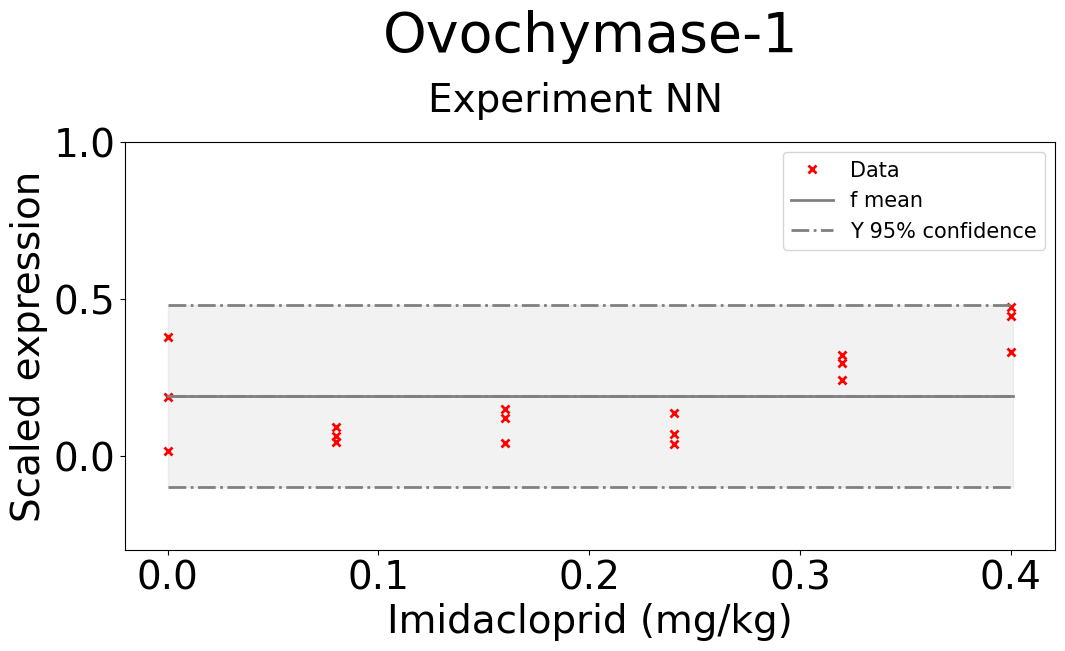

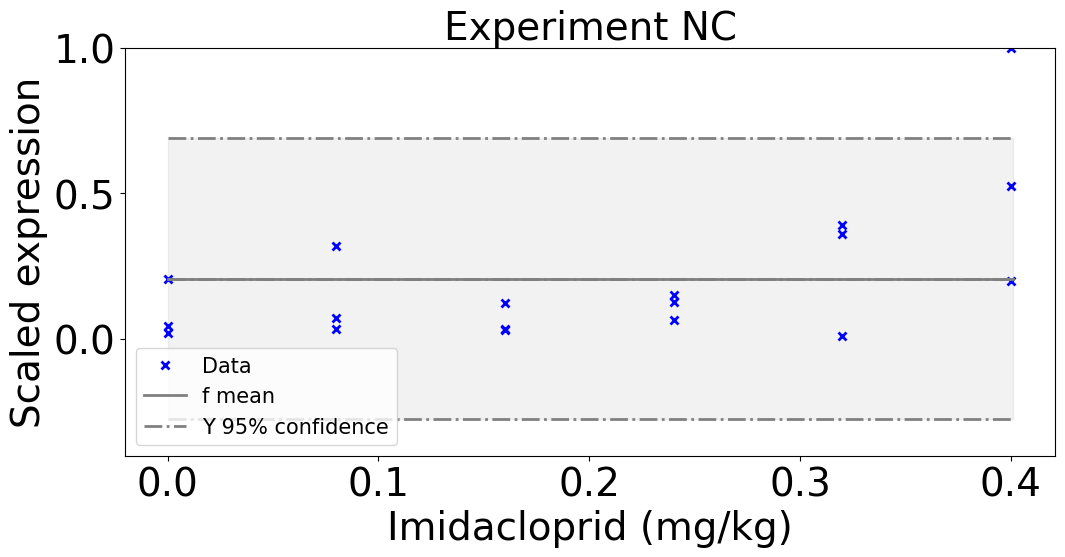

Noise likelihood -0.07546332563298819


In [17]:
plot_noise = True
if(plot_noise):

    """
    Fit two models on exp1
    """
    m_noise, lik_noise = fit_noise(data_exp1, init_variance)
    
    mlik_noise_exp1.append(lik_noise)


    xx = np.linspace(0.0, 0.401, 100).reshape(100, 1)  # test points must be of shape (N, D)

    ## predict mean and variance of latent GP at test points
    mean_noise, var_noise = m_noise.predict_f(xx)
    mean_y_noise, var_y_noise = m_noise.predict_y(xx)
    
    

    # # Plot predicted model
    plt.figure(figsize=(12, 6))
    plt.plot(X_exp1.flatten(), Y_exp1.flatten(), 'rx', mew=2, label="Data")
    plt.plot(xx[:, 0], mean_noise[:, 0], 'gray', lw=2, label="f mean")
    plt.plot(xx[:, 0], mean_noise[:, 0] - 2 * np.sqrt(var_noise[:, 0]), color='gray', linestyle='dashdot', lw=2)
    plt.plot(xx[:, 0], mean_noise[:, 0] + 2 * np.sqrt(var_noise[:, 0]), color='gray', linestyle='dashdot', lw=2)

    plt.plot(xx[:, 0], mean_y_noise[:, 0] - 2 * np.sqrt(var_y_noise[:, 0]), color='gray', linestyle='dashdot', lw=2, label="Y 95% confidence")
    plt.plot(xx[:, 0], mean_y_noise[:, 0] + 2 * np.sqrt(var_y_noise[:, 0]), color='gray', linestyle='dashdot', lw=2)

    plt.fill_between(xx[:, 0],
                     mean_noise[:, 0] - 2 * np.sqrt(var_noise[:, 0]),
                     mean_noise[:, 0] + 2 * np.sqrt(var_noise[:, 0]),
                     color='gray',
                     alpha=0.1)

    plt.fill_between(xx[:, 0],
                 mean_y_noise[:, 0] - 2 * np.sqrt(var_y_noise[:, 0]),
                 mean_y_noise[:, 0] + 2 * np.sqrt(var_y_noise[:, 0]),
                 color='gray',
                 alpha=0.1)

    plt.tick_params(axis='x', labelsize=28)
    plt.tick_params(axis='y', labelsize=28)
    plt.xlabel('Imidacloprid (mg/kg)', fontsize=28)
    plt.ylabel('Scaled expression', fontsize=28)
    #plt.title('Experiment NN', fontsize=28)
    plt.title('Ovochymase-1\n', fontsize=40, pad=20)
    plt.suptitle('Experiment NN\n', fontsize=28)
    plt.subplots_adjust(bottom=0.2)
    plt.ylim(-0.3,1)
    #plt.legend(fontsize=15)
    plt.legend(fontsize=15)
    plt.savefig('example_noise_exp1_'+str(gene_id)+'.png', bbox_inches='tight')
    plt.show()
    plt.close()


    """
    Fit two models on imidacloprid
    """
    #try:
    # fit rbf _imidacloprid
    data_exp2 = (X_exp2.reshape(-1,1), Y_exp2.reshape(-1,1))
    
    m_noise, lik_noise = fit_noise(data_exp2, init_variance)
    
    mlik_noise_exp2.append(lik_noise)

    xx = np.linspace(0.0, 0.401, 100).reshape(100, 1)  # test points must be of shape (N, D)

    ## predict mean and variance of latent GP at test points
    mean_noise, var_noise = m_noise.predict_f(xx)
    

    xx = np.linspace(0.0, 0.401, 100).reshape(100, 1)  # test points must be of shape (N, D)

    ## predict mean and variance of latent GP at test points
    mean_noise, var_noise = m_noise.predict_f(xx)
    mean_y_noise, var_y_noise = m_noise.predict_y(xx)

    # Plot predicted model
    plt.figure(figsize=(12, 6))
    plt.plot(X_exp2.flatten(), Y_exp2.flatten(), 'bx', mew=2, label='Data')
    plt.plot(xx[:, 0], mean_noise[:, 0], 'gray', lw=2, label="f mean")
    plt.plot(xx[:, 0], mean_noise[:, 0] - 2 * np.sqrt(var_noise[:, 0]), color='gray', linestyle='dashdot', lw=2)
    plt.plot(xx[:, 0], mean_noise[:, 0] + 2 * np.sqrt(var_noise[:, 0]), color='gray', linestyle='dashdot', lw=2)

    plt.plot(xx[:, 0], mean_y_noise[:, 0] - 2 * np.sqrt(var_y_noise[:, 0]), color='gray', linestyle='dashdot', lw=2, label="Y 95% confidence")
    plt.plot(xx[:, 0], mean_y_noise[:, 0] + 2 * np.sqrt(var_y_noise[:, 0]), color='gray', linestyle='dashdot', lw=2)

    plt.fill_between(xx[:, 0],
                     mean_noise[:, 0] - 2 * np.sqrt(var_noise[:, 0]),
                     mean_noise[:, 0] + 2 * np.sqrt(var_noise[:, 0]),
                     color='gray',
                     alpha=0.1)

    plt.fill_between(xx[:, 0],
                 mean_y_noise[:, 0] - 2 * np.sqrt(var_y_noise[:, 0]),
                 mean_y_noise[:, 0] + 2 * np.sqrt(var_y_noise[:, 0]),
                 color='gray',
                 alpha=0.1)

    plt.xlabel('Imidacloprid (mg/kg)', fontsize=28)
    plt.ylabel('Scaled expression', fontsize=28)
    plt.tick_params(axis='x', labelsize=28)
    plt.tick_params(axis='y', labelsize=28)
    plt.title('Experiment NC', fontsize=28)
    plt.subplots_adjust(bottom=0.2)
    plt.ylim(-0.4,1)
    plt.legend(fontsize=15)
    plt.savefig('example_noise_exp2_'+str(gene_id)+'.png',bbox_inches='tight')
    plt.show()

    mean, var = m.predict_f(X_exp2.reshape(-1,1))

    t_df.append(X_exp1.reshape(-1,1))
    trt_df.append(np.repeat('imi',6))
    y_df.append(np.asarray(mean).flatten())
    ID_df.append(np.repeat(gene_id,6))

    print('Noise likelihood', lik_noise)


In [20]:
# Chi-2 test
print(chi2.sf(2*(np.array(-mlik_rbf_exp1[0]) - (-mlik_noise_exp1[0])),1))
print(chi2.sf(2*(np.array(-mlik_rbf_exp2[0]) - (-mlik_noise_exp2[0])),1))

0.012455137202366835
0.6057762452793651
